In [2]:
import numpy as np  
import matplotlib.pyplot as plt
from Utilities import extractor, cb_pdf

#Estraiamo i dati 

x_MH50= extractor("Dati/Tprime_tAq_1800_MH50_LH_2017.root", "Events")

#Filtriamo i dati per rimuovere outliers
x_filtered = 0

/home/riccardo/anaconda3/envs/rootnev/lib/python3.14/site-packages/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /home/riccardo/anaconda3/envs/rootnev/include/site/python3.14); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "
/home/riccardo/anaconda3/envs/rootnev/lib/python3.14/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


In [3]:
#Capiamo come filtrare i dati
import uproot
import awkward as ak

file=uproot.open("Dati/Tprime_tAq_1800_MH50_LH_2017.root")
tree=file["Events"]
booleans= tree.arrays(["FatJet_isMatchedWithA"], library="ak")
Fatjet_isMatchedWithA= booleans["FatJet_isMatchedWithA"]
print(Fatjet_isMatchedWithA)
print(type(Fatjet_isMatchedWithA))


[[1, 0, 0], [0, 1], [1], [0, 1], [...], ..., [1, 0], [1, 0], [1, 0, 0], [1, 0]]
<class 'awkward.highlevel.Array'>


In [ ]:
#Applichiamo il filtro
mask = ak.flatten(Fatjet_isMatchedWithA) == 1
x_filtered = x_MH50[mask]
print(x_filtered) 
print(type(x_filtered))
print(len(x_filtered))



[49.8, 50.3, 49.3, 51.9, 49.1, 41.4, 50.7, ..., 50.1, 210, 182, 49.4, 59, 49.9]
<class 'awkward.highlevel.Array'>
56168


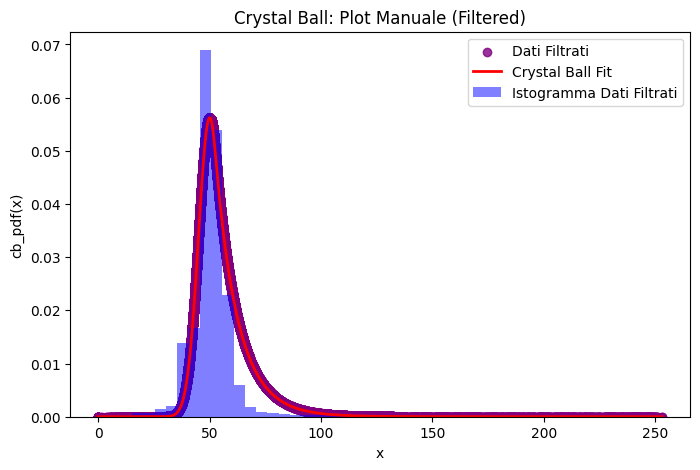

In [5]:
#Facciamo il fit dei dati filtrati

y_filtered=cb_pdf(x_filtered,mu=50,sigma=5,beta=0.5, m=30.0001)

x_plot=list(x_filtered)
x_plot.sort()
y_plot=[cb_pdf(xi,mu=50,sigma=5,beta=0.5, m=30.0001) for xi in x_plot]

fig = plt.figure(figsize=(8, 5))
plt.scatter(x_filtered, y_filtered, color="purple", alpha=0.8, label="Dati Filtrati")
plt.plot(x_plot, y_plot, color="red", alpha=1, linewidth=2, label="Crystal Ball Fit")
plt.hist(x_filtered, bins=50, density=True, alpha=0.5, color="blue", label="Istogramma Dati Filtrati", weights=np.ones_like(x_filtered) / len(x_filtered))
plt.title("Crystal Ball: Plot Manuale (Filtered)")
plt.xlabel("x")
plt.ylabel("cb_pdf(x)")
plt.legend()
plt.show()  


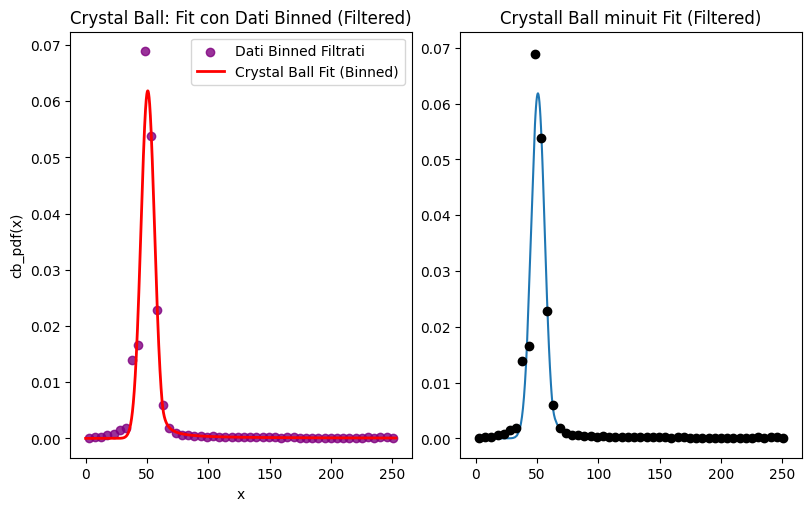

In [6]:
#Ora facciamo il fit con i dati binned
from iminuit import Minuit
from iminuit.cost import LeastSquares


bin_counts, bin_edges = np.histogram(x_plot, bins=50)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]
bin_densities = bin_counts / (len(x_plot) * bin_width)  # Densità normalizzata
yerr=np.sqrt(bin_counts) / (len(x_plot) * bin_width) # Errore standard per i dati binned

ls=LeastSquares(bin_centers, bin_densities, yerr, model=cb_pdf)

m=Minuit(ls, mu=50, sigma=5, beta=0.5, m=30.0001)
m.limits["mu"]= (45, 65)
m.limits["sigma"]= (0.1, 20)
m.limits["beta"]= (0.1, 10)
m.limits["m"]= (0.1, 100)
m.migrad()  

fig, ax= plt.subplots(1, 2, figsize=(8, 5), sharex=True, constrained_layout=True)
plt.sca(ax[0])
plt.scatter(bin_centers, bin_densities, color="purple", alpha=0.8, label="Dati Binned Filtrati")
plt.plot(x_plot, [cb_pdf(xi, *m.values) for xi in x_plot], color="red", alpha=1, linewidth=2, label="Crystal Ball Fit (Binned)")
plt.title("Crystal Ball: Fit con Dati Binned (Filtered)")
plt.xlabel("x")
plt.ylabel("cb_pdf(x)")
plt.legend()    

plt.sca(ax[1])
m.visualize()
plt.title("Crystall Ball minuit Fit (Filtered)")
plt.show()

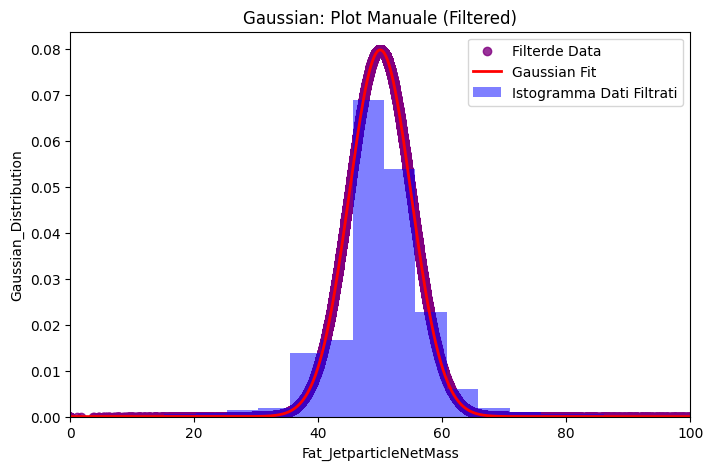

In [7]:
#Proviamo ora con una Gaussiana
from numba_stats import  truncnorm

def gaussian(x, mu, sigma):
    return truncnorm.pdf(x,*x_range, loc=mu, scale=sigma)

#Facciamo prima il fit e poi lo ottimizziamo con minuit

x_gauss=list(x_filtered)
x_gauss.sort()
x_range=(0, max(x_filtered))
y_gauss=gaussian(x_gauss, mu=50, sigma=5)

fix= plt.figure(figsize=(8, 5))

plt.scatter(x_gauss, y_gauss, color="purple", alpha=0.8, label="Filterde Data")
plt.plot(x_gauss, y_gauss, color="red", alpha=1, linewidth=2, label="Gaussian Fit")
plt.hist(x_filtered, bins=50, density=True, alpha=0.5, color="blue", label="Istogramma Dati Filtrati", weights=np.ones_like(x_filtered) / len(x_filtered))
plt.xlim(0, 100)
plt.title("Gaussian: Plot Manuale (Filtered)")
plt.xlabel("Fat_JetparticleNetMass")
plt.ylabel("Gaussian_Distribution")
plt.legend()





In [12]:
#Ora minimizziamo con minuit
ls_gauss=LeastSquares(bin_centers, bin_densities, yerr, model=gaussian)
m_gauss=Minuit(ls_gauss, mu=50, sigma=5)
m_gauss.limits["mu"]= (45, 65)
m_gauss.limits["sigma"]= (0.1, 20)
m_gauss.migrad()


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 8699 (χ²/ndof = 181.2)     │              Nfcn = 42               │
│ EDM = 9.56e-10 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ mu    │  50.690   │   0.023   │            │            │   45    │   65    │       │
│ 1 │ sigma │   5.819   │   0.029   │            │            │   0.1   │   20    │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬───────────────────┐
│       │       mu    sigma │
├───────┼───────────────────┤
│    mu │ 0.000539  -0.1e-3 │
│ sigma │  -0.1e-3 0.000824 │
└───────┴───────────────────┘

In [ ]:
fig, ax= plt.subplots(1, 2, figsize=(8, 5), sharex=True, constrained_layout=True)
plt.sca(ax[0])
plt.scatter(bin_centers, bin_densities, color="purple", alpha=0.8, label="Filtered Binned Data")
plt.plot(x_plot, [gaussian(xi, *m_gauss.values) for xi in x_plot], color="red", alpha=1, linewidth=2, label="Gaussian Fit (Binned)")
plt.title("Gaussian: Fit con Dati Binned (Filtered)")
plt.xlabel("x")
plt.ylabel("Gaussian(x)")
plt.legend()    
plt.sca(ax[1])
m_gauss.visualize()
plt.title("Gaussian minuit Fit (Filtered)")
plt.show()


In [9]:
#Facciamo il test di chi quadro per vedere quale fit è migliore
import scipy.stats as stats

#Iniziamo con la Crystal Ball, ovvimete usiamo i dati binned minimizzati da Minuit
chi_quandro_mninimo_cb=m.fval
gradi_libertà=m.ndof

p_valore=stats.chi2.sf(chi_quandro_mninimo_cb, gradi_libertà)
print(f"Chi quadro Crystal Ball: {chi_quandro_mninimo_cb}, gradi di libertà :{gradi_libertà} p-value: {p_valore}")

#Proviamo a fare lo stesso con la Gaussiana

chi_quadro_minimo_gauss=m_gauss.fval
gradi_libertà_gauss=m_gauss.ndof
p_valore_gauss=stats.chi2.sf(chi_quadro_minimo_gauss, gradi_libertà_gauss)
print(f"Chi quadro Gaussiana: {chi_quadro_minimo_gauss}, gradi di libertà :{gradi_libertà_gauss} p-value: {p_valore_gauss}")

print(type(p_valore), type(p_valore_gauss))

print(f"p-value Crystal Ball: {p_valore:.4f}, p-value Gaussiana: {p_valore_gauss:.4f}")

Chi quadro Crystal Ball: 5100.112320871677, gradi di libertà :46.0 p-value: 0.0
Chi quadro Gaussiana: 8698.698066199337, gradi di libertà :48.0 p-value: 0.0
<class 'numpy.float64'> <class 'numpy.float64'>
p-value Crystal Ball: 0.0000, p-value Gaussiana: 0.0000


In [11]:
#Proviamo ora con la gaussaiana interpolata con Breit-Wigner
from scipy.special import voigt_profile
from scipy.optimize import curve_fit

def voigt(x, norm, mu, sigma, gamma):
    return voigt_profile(x-mu, sigma, gamma) * norm

bin_counts, bin_edges = np.histogram(x_plot, bins=50)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]
bin_densities = bin_counts / (len(x_plot) * bin_width)  # Densità normalizzata
yerr=np.sqrt(bin_counts) / (len(x_plot) * bin_width) # Errore standard per i dati binned

ls_voigt=LeastSquares(bin_centers, bin_densities, yerr, model=voigt)

m_voigt=Minuit(ls_voigt,  norm=1, mu=50, sigma=5, gamma=1)
m_voigt.limits["mu"]= (45, 65)
m_voigt.limits["sigma"]= (0.1, 20)
m_voigt.limits["gamma"]= (0.01, 10)
#m_voigt.limits["norm"]= (0.1, 20)
m_voigt.migrad()





┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3232 (χ²/ndof = 70.3)      │              Nfcn = 100              │
│ EDM = 4.6e-05 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ norm  │   0.959   │   0.004   │            │            │         │         │       │
│ 1 │ mu    │  50.522   │   0.027   │            │            │   45    │   65    │       │
│ 2 │ sigma │   3.60    │   0.05    │            │            │   0.1   │   20    │       │
│ 3 │ gamma │   2.125   │   0.032   │            │            │  0.01   │   10    │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬─────────────────────────────────────────┐
│       │      norm        mu     sigma     gamma │
├───────┼─────────────────────────────────────────┤
│  norm │  1.74e-05 -0.002e-3 -0.009e-3  0.008e-3 │
│    mu │ -0.002e-3  0.000713    0.4e-3   -0.2e-3 │
│ sigma │ -0.009e-3    0.4e-3   0.00225   -0.0011 │
│ gamma │  0.008e-3   -0.2e-3   -0.0011   0.00103 │
└───────┴─────────────────────────────────────────┘

In [ ]:
import json

fit_MH50_values={}

for param in m_voigt.parameters:
    fit_MH50_values[param] = m_voigt.values[param]

print(fit_MH50_values)


with open("fit_results.json", "w") as f:
    json.dump(fit_MH50_values, f)

